# Kaggle Housing Price Prediction
Notebook for the *Housing Prices Competition for Kaggle Learn Users*

In [164]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

from pandas.api.types import CategoricalDtype

from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor

import optuna

# set global theme and disable frames
sns.set_theme(style = 'white',
              rc={'legend.frameon': False},
              )
sns.set_style('ticks', {'xtick.major.size' : 8,
                        'ytick.major.size' : 8,
                        'xtick.bottom'     : True,
                        'ytick.left'       : True,
                        })

## Explore Preprocessing for Test Data

In [7]:
# Load the Kaggle dataset
path_train = './input/train.csv.gz'
train = pd.read_csv(path_train, compression='gzip', index_col='Id')

print(f'Shape of train_full dataset: {train.shape}')

Shape of train_full dataset: (1460, 80)


### Address Missing Data

In [8]:
# look for columns with a lot of missing data
missing_count = train.isnull().sum().sort_values(ascending=False)
missing_pct   = ((train.isnull().sum() / train.isnull().count()).sort_values(ascending=False) * 100).astype(int).astype(str) + '%'
missing_data  = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,99%
MiscFeature,1406,96%
Alley,1369,93%
Fence,1179,80%
MasVnrType,872,59%
FireplaceQu,690,47%
LotFrontage,259,17%
GarageQual,81,5%
GarageType,81,5%
GarageFinish,81,5%


In [9]:
# some columns here are nan for no feature so we can encode that instead of keeping values nan
train['PoolQC']        = train['PoolQC'].fillna('NA')
train['MiscFeature']   = train['MiscFeature'].fillna('NA')
train['Alley']         = train['Alley'].fillna('NA')
train['Fence']         = train['Fence'].fillna('NA')
train['MasVnrType']    = train['MasVnrType'].fillna('NA')
train['FireplaceQu']   = train['FireplaceQu'].fillna('NA')
train['GarageQual']    = train['GarageQual'].fillna('NA')
train['GarageFinish']  = train['GarageFinish'].fillna('NA')
train['GarageType']    = train['GarageType'].fillna('NA')
train['GarageCond']    = train['GarageCond'].fillna('NA')
train['BsmtFinType2']  = train['BsmtFinType2'].fillna('NA')
train['BsmtExposure']  = train['BsmtExposure'].fillna('NA')
train['BsmtCond']      = train['BsmtCond'].fillna('NA')
train['BsmtQual']      = train['BsmtQual'].fillna('NA')
train['BsmtFinType1']  = train['BsmtFinType1'].fillna('NA')

# no definition for nan in Electrical, only 1 missing so impute with mode
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# check which columns are remaining
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
MSSubClass       0
Street           0
dtype: int64


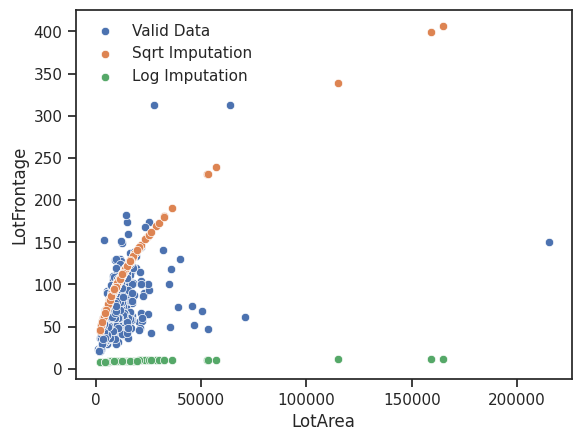

In [10]:
# figure out what to do with LotFrontage

# guess how to impute nans by filling with a transformation of LotArea
train['RootArea'] = np.sqrt(train['LotArea'])
train['LogArea']  = np.log(train['LotArea'])

fig, ax = plt.subplots()

sns.scatterplot(data=train, x='LotArea', y='LotFrontage', label='Valid Data')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='RootArea', label='Sqrt Imputation')
sns.scatterplot(data=train[train['LotFrontage'].isna()], x='LotArea', y='LogArea', label='Log Imputation')

ax.legend()
plt.show()

# filling missing LotFrontage with the root of LotArea seems to agree
# reasonably well with the bulk of the data so it's probalby good
# enough for now
train['LotFrontage'] = train['LotFrontage'].fillna(train['RootArea'])

train = train.drop(columns=['RootArea', 'LogArea'])

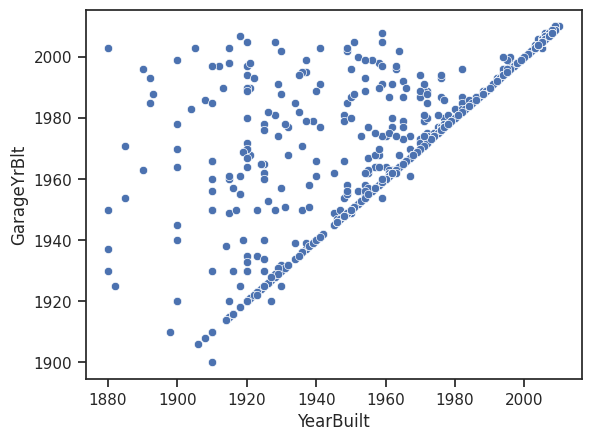

In [11]:
# figure out what to do wtih GarageYrBlt

sns.scatterplot(train, x='YearBuilt', y='GarageYrBlt')
plt.show()

# nan here probably means that there is no garage so just make a new
# HasGarage to flag this and impute missing values with YearBuilt
# so missing values are roughly in line with rest of the data
train['HasGarage']   = (~train['GarageYrBlt'].isna()).astype(int)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])

# looks like some data has the garage built before the house?
# just set these values to YearBuilt
train.loc[train['GarageYrBlt'] < train['YearBuilt'], 'GarageYrBlt'] = train['YearBuilt']

      MasVnrArea MasVnrType
Id                         
235          NaN         NA
530          NaN         NA
651          NaN         NA
937          NaN         NA
974          NaN         NA
978          NaN         NA
1244         NaN         NA
1279         NaN         NA


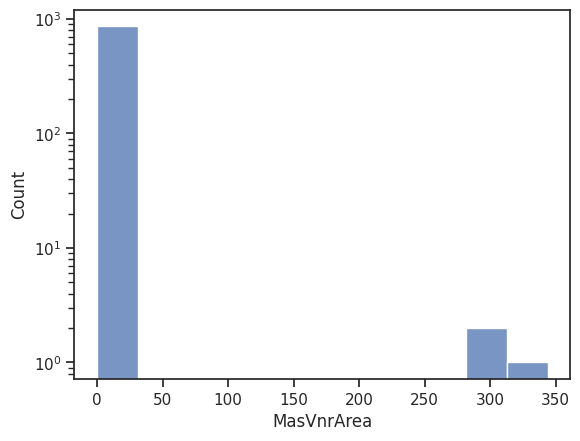

In [12]:
# figure out what to do with MasVnrArea

# MasVnrArea is only nan when MasVnrType is NA
print(train[train['MasVnrArea'].isna()][['MasVnrArea', 'MasVnrType']])

# most MasVnrArea values are 0 when MasVnrType is NA so just impute with 0
sns.histplot(train[train['MasVnrType'] == 'NA']['MasVnrArea'])
plt.yscale('log')
plt.show()

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

In [13]:
# confirm there is no more missing data
print(f'Remaining NaN values:\n{train.isnull().sum().sort_values(ascending=False).head()}')

Remaining NaN values:
MSSubClass     0
MSZoning       0
LotFrontage    0
LotArea        0
Street         0
dtype: int64


In [14]:
def clean(df):
    '''
    Applies preliminary data cleaning to the provided
    dataframe based on the cells above
    '''
    # set missing GarageYrBlt values to YearBuilt
    df.loc[df['GarageYrBlt'] < df['YearBuilt'], 'GarageYrBlt'] = df['YearBuilt']

    return df


def impute(df, impute_stats=None):
    '''
    Impute the columns in the provided dataframe
    based on the results of the cells above

    impute_stats is a dict that specifies values to
    use for imputing that need to be collected from
    training data 
    '''
    # first handle special cases

    # estimate missing LotFrontage by the root of LotArea
    df['RootArea']    = np.sqrt(df['LotArea'])
    df['LotFrontage'] = df['LotFrontage'].fillna(df['RootArea'])
    df = df.drop(columns=['RootArea'])

    # set missing GarageYrBlt with YearBuilt
    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])

    # impute the missing Electrical data with the mode
    if impute_stats is None:
        impute_stats = {'Electrical' : df['Electrical'].mode()[0]}
    
    df['Electrical'] = df['Electrical'].fillna(impute_stats['Electrical'])


    # general handling for the rest of the columns
    for col in df.select_dtypes('object', 'category'):
        df[col] = df[col].fillna('NA')
    
    for col in df.select_dtypes('number'):
        df[col] = df[col].fillna(0)
    
    return df, impute_stats

### Encode Categorical Data

In [161]:
def encode(df):
    '''
    Encode the categorical columns of the provided dataframe
    based on the encoding outlined below
    '''
    # categorical columns
    categorical_cols = set(df.select_dtypes('object', 'category').columns)

    nominative_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
                    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
                    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'Functional',
                    'MiscFeature', 'SaleType', 'SaleCondition', 'GarageType']

    ordinal_cols = list(categorical_cols - set(nominative_cols))

    ordinal_encoding = {'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
                        'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
                        'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtQual'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtCond'      : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'BsmtExposure'  : ['No', 'Mn', 'Av', 'Gd'],
                        'BsmtFinType1'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'BsmtFinType2'  : ['Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
                        'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'CentralAir'    : ['N', 'Y'],
                        'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'FireplaceQu'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageQual'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageCond'    : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                        'GarageFinish'  : ['Unf', 'RFn', 'Fin'],
                        'PavedDrive'    : ['N', 'P', 'Y'],
                        'PoolQC'        : ['Fa', 'TA', 'Gd', 'Ex'],
                        'Fence'         : ['MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
                        }

    ordinal_encoding = {key: ['NA'] + values for key, values in ordinal_encoding.items()}

    for col in nominative_cols:
        df[col] = df[col].astype('category')
    
    for col in ordinal_cols:
        df[col] = df[col].astype(CategoricalDtype(ordinal_encoding[col], ordered=True))
    
    return df

## Load Data and Apply Preprocessing

In [162]:
def load_data():
    # Load the Kaggle dataset
    path_train = './input/train.csv.gz'
    path_test  = './input/test.csv.gz'

    train_full = pd.read_csv(path_train, compression='gzip', index_col='Id')
    test_full  = pd.read_csv(path_test, compression='gzip', index_col='Id')

    train = train_full.copy()
    train = clean(train)
    train, impute_stats = impute(train)
    train = encode(train)

    test = test_full.copy()
    test = clean(test)
    test, _ = impute(test, impute_stats)
    test = encode(test)

    return train, test

train, test = load_data()

print(f'Shape of train dataset: {train.shape}')
print(f'Shape of test dataset:  {test.shape}')

# remove training rows with missing target (SalePrice)
print(f'{train["SalePrice"].isna().sum()} trainig rows have a missing SalePrice')
train = train.dropna(subset=['SalePrice']) # no missing SalePrice so not needed

# remove any duplicate training rows
print(f'{train.duplicated().sum()} trainig rows are duplicates')
train = train.drop_duplicates(keep='first') # no duplicates so not needed

Shape of train dataset: (1460, 80)
Shape of test dataset:  (1459, 79)
0 trainig rows have a missing SalePrice
0 trainig rows are duplicates


## Make Baseline Model

In [17]:
def score_model(X, y, model=XGBRegressor()):
    '''
    Return a score using cross validation to estimate
    model performance. This competition uses RMSE between
    log prices so use that as a metric
    '''
    # convert categorical columns to their code values
    for col in X.select_dtypes(['category']).columns:
        X[col] = X[col].cat.codes
    
    # scoring based on difference in log price
    log_y = np.log(y)
    score = cross_val_score(model, X, log_y, cv=5, scoring='neg_mean_squared_error')
    score = -1 * score.mean()
    score = np.sqrt(score)
    return score

In [18]:
X = train.copy()
y = X.pop('SalePrice')

baseline_score = score_model(X, y)
print(f'Baseline model score: {baseline_score:.5f} RMSE')

Baseline model score: 0.14079 RMSE


## Investigate Utility Scores using Mutual Information

In [19]:
def get_mi_scores(X, y):
    '''
    Calculate mutual information scores between columns
    in X and target in y
    '''
    X = X.copy()
    for col in X.select_dtypes(['category']):
        X[col] = X[col].cat.codes

    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=123)
    mi_scores = pd.Series(mi_scores, name='MI Scores', index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)

    return mi_scores


def plot_mi_scores(scores):
    '''
    Create a bar plot of mutual information scores
    '''
    scores = scores.sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(4, 12))

    sns.barplot(x=scores.values, y=scores.index)

    ax.tick_params(axis='both', labelsize=8)
    ax.set_ylabel('Column')
    ax.set_xlabel('Mutual Information Score')
    
    plt.show()

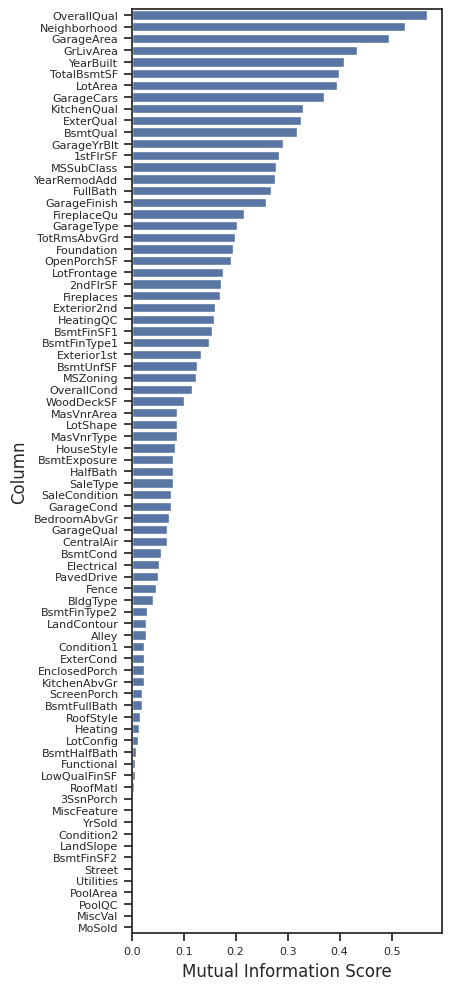

In [20]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)
plot_mi_scores(mi_scores)

In [21]:
# Delete columns with 0 mutual information so model isn't overfitting.
# Some columns like Poolxxx are mostly 0 or NA because most houses
# don't have pools so this is a reasonable candidate to drop

def drop_uninformative(df, mi_scores):
    print('Dropping the following uninformative columns:')
    print(list(mi_scores[mi_scores == 0.0].index))
    return df.loc[:, mi_scores > 0.0]

X = train.copy()
y = X.pop('SalePrice')
X = drop_uninformative(X, mi_scores)

# removing these seems to help a little bit
print(f'Score after removing uninformative features: {score_model(X, y):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Score after removing uninformative features: 0.13925 RMSE


## Engineer Additional Features to Improve Model Score

In [ ]:
def combinations(df):
    '''
    Creates a dataframe of new columns X which
    are meaningful mathematical transformations
    of the columns in df 
    '''
    X = pd.DataFrame(index=df.index)
    X['LivLotRatio']  = df['GrLivArea'] / df['LotArea']
    X['Spaciousness'] = (df['1stFlrSF'] + df['2ndFlrSF']) / df['TotRmsAbvGrd']
    X['TotBath']      = df[['BsmtFullBath', 'FullBath']].sum(axis=1) + 0.5 * df[['BsmtHalfBath', 'HalfBath']].sum(axis=1)

    return X


def group_transforms(df, group_stats=None):
    '''
    Creates a dataframe of new columns which are group-level
    statistics per Neighborhood, computed from training data only.

    group_stats: dict of pre-computed Series (fit on train).
                 If None, stats are computed from df — only pass
                 None when df is the training set.
    '''
    if group_stats is None:
        group_stats = {
            'MedNhbdLivArea'  : df.groupby('Neighborhood', observed=False)['GrLivArea'].median(),
            'StdvNhbdLivArea' : df.groupby('Neighborhood', observed=False)['GrLivArea'].std(),
            'MeanNhbdLotArea' : df.groupby('Neighborhood', observed=False)['LotArea'].mean(),
        }

    X = pd.DataFrame(index=df.index)
    X['MedNhbdLivArea']  = df['Neighborhood'].map(group_stats['MedNhbdLivArea'])
    X['StdvNhbdLivArea'] = df['Neighborhood'].map(group_stats['StdvNhbdLivArea'])
    X['MedNhbdLivDiff']  = df['GrLivArea'] - X['MedNhbdLivArea']
    X['MeanNhbdLotArea'] = df['Neighborhood'].map(group_stats['MeanNhbdLotArea'])

    return X, group_stats

In [145]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)

X = drop_uninformative(X, mi_scores)
X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

print(f'Model score: {score_model(X, y):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Model score: 0.13640 RMSE


## Look for Outliers in SalePrice
Use columns with the highest mutual information and correlation

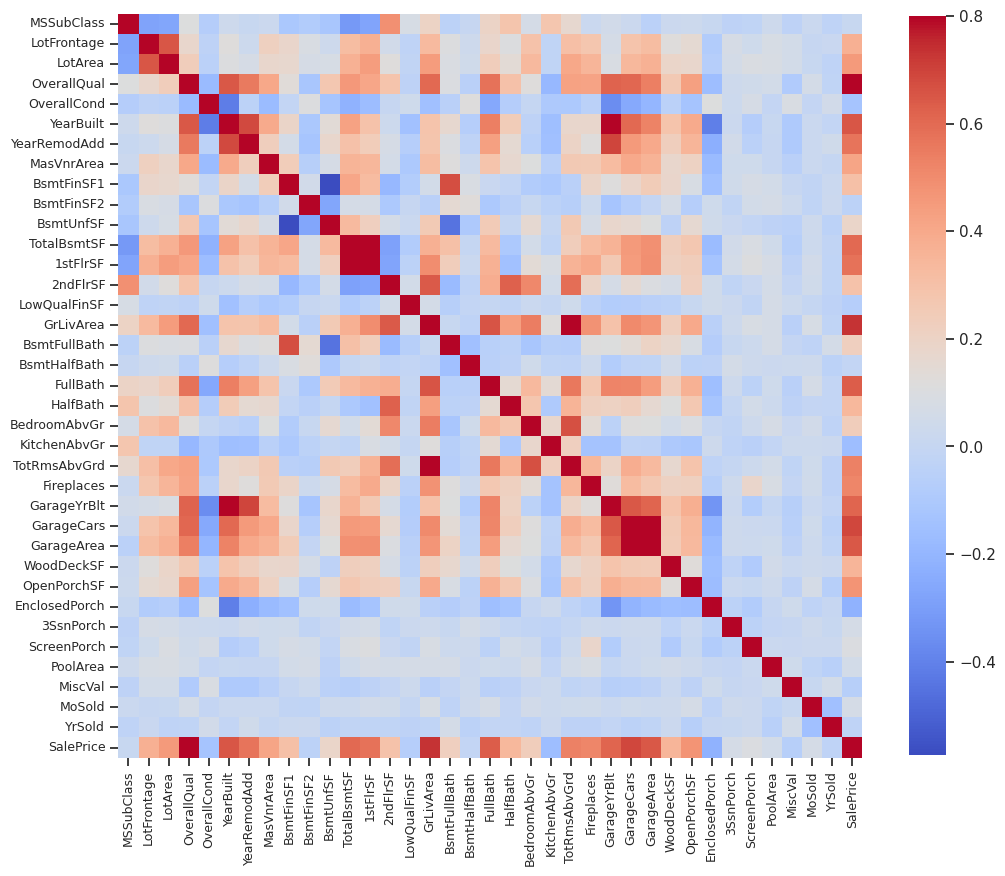

In [77]:
correlation_matrix = train.corr(method='spearman', numeric_only=True) # spearman to account for non-linearity

fig, ax = plt.subplots(figsize=(12,12))
sns.heatmap(correlation_matrix, vmax=0.8, square=True, cbar_kws={'shrink': 0.8}, cmap='coolwarm')

ax.tick_params(axis='both', labelsize=9)
plt.show()

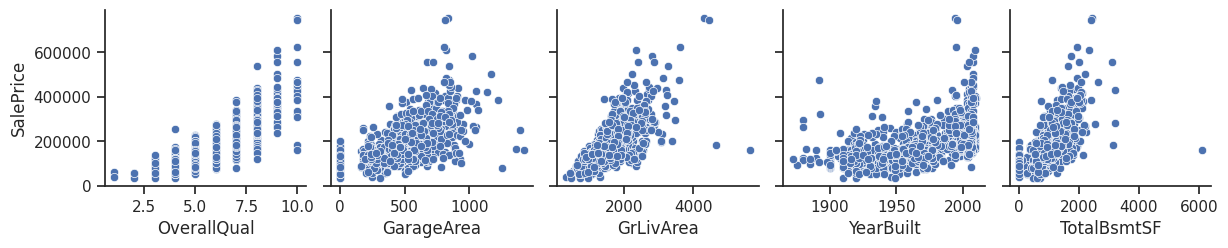

In [ ]:
# see outliers in garage area, GrLivArea, and TotalBsmtSF
correlated_cols = ['OverallQual', 'GarageArea', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF']
sns.pairplot(data=train, y_vars='SalePrice', x_vars=correlated_cols)
plt.show()

In [ ]:
cols_to_investigate = ['SalePrice', 'Neighborhood', 'SaleCondition', 'BldgType', 'MSZoning', 'MSSubClass'] + correlated_cols
train[train['GarageArea'] > 1200][cols_to_investigate].sort_values('GarageArea', ascending=False)

,SalePrice,Neighborhood,SaleCondition,BldgType,MSZoning,MSSubClass,OverallQual,GarageArea,GrLivArea,YearBuilt,TotalBsmtSF
Id,,,,,,,,,,,
1299,160000,Edwards,Partial,1Fam,RL,60,10,1418,5642,2008,6110
582,253293,NridgHt,Partial,1Fam,RL,20,8,1390,2042,2008,2042
1191,168000,Mitchel,Normal,2fmCon,RL,190,4,1356,1622,1961,1249
1062,81000,IDOTRR,Normal,1Fam,C (all),30,3,1248,894,1935,894
826,385000,NridgHt,Partial,1Fam,RL,20,10,1220,2084,2007,2078


In [87]:
train[train['GrLivArea'] > 4000][cols_to_investigate].sort_values('GrLivArea', ascending=False)

,SalePrice,Neighborhood,SaleCondition,BldgType,MSZoning,MSSubClass,OverallQual,GarageArea,GrLivArea,YearBuilt,TotalBsmtSF
Id,,,,,,,,,,,
1299,160000,Edwards,Partial,1Fam,RL,60,10,1418,5642,2008,6110
524,184750,Edwards,Partial,1Fam,RL,60,10,884,4676,2007,3138
1183,745000,NoRidge,Abnorml,1Fam,RL,60,10,813,4476,1996,2396
692,755000,NoRidge,Normal,1Fam,RL,60,10,832,4316,1994,2444


In [ ]:
train[train['TotalBsmtSF'] > 2500][cols_to_investigate].sort_values('TotalBsmtSF', ascending=False)

,SalePrice,Neighborhood,SaleCondition,BldgType,MSZoning,MSSubClass,OverallQual,GarageArea,GrLivArea,YearBuilt,TotalBsmtSF
Id,,,,,,,,,,,
1299,160000,Edwards,Partial,1Fam,RL,60,10,1418,5642,2008,6110
333,284000,NridgHt,Normal,1Fam,RL,20,8,880,1629,2003,3206
497,430000,NoRidge,Normal,1Fam,RL,20,8,546,3228,1992,3200
524,184750,Edwards,Partial,1Fam,RL,60,10,884,4676,2007,3138
441,555000,NridgHt,Normal,1Fam,RL,20,10,672,2402,2008,3094
1374,466500,NoRidge,Normal,1Fam,RL,20,10,804,2633,2001,2633
1045,278000,NWAmes,Normal,1Fam,RL,20,8,542,2524,1981,2524


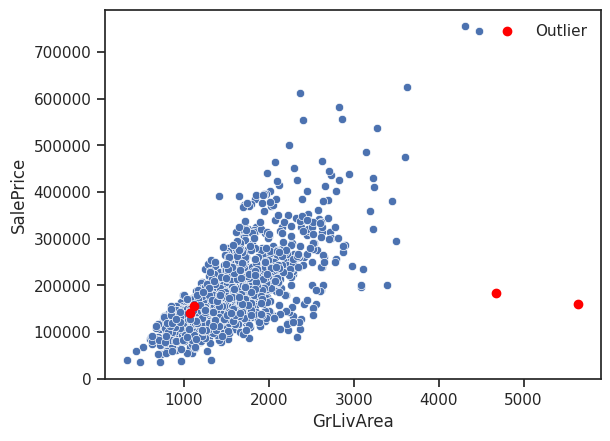

In [ ]:
# plot outliers to see how many points are impacted by this filter
outlier_index = train[(train['Neighborhood'] == 'Edwards') & (train['SaleCondition'] == 'Partial')].index

fig, ax = plt.subplots()

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice')

# highlight the outliers
ax.scatter(train.loc[outlier_index, 'GrLivArea'], train.loc[outlier_index, 'SalePrice'],
            color='red', zorder=5, label=f'Outlier')

ax.set_xlabel('GrLivArea')
ax.set_ylabel('SalePrice')

ax.legend()
plt.show()

In [98]:
def indicate_outliers(df):
    outlier_df            = pd.DataFrame()
    outlier_df['Outlier'] = (df['Neighborhood'] == 'Edwards') & (df['SaleCondition'] == 'Partial')

    return outlier_df

In [146]:
X = train.copy()
y = X.pop('SalePrice')

mi_scores = get_mi_scores(X, y)

X = drop_uninformative(X, mi_scores)
X = X.join(combinations(X))

group_features, group_stats = group_transforms(X)
X = X.join(group_features)

X = X.join(indicate_outliers(X))

print(f'Model score: {score_model(X, y):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Model score: 0.13632 RMSE


## Create Final Feature Set

In [166]:
def create_features(df, df_test=None):
    '''
    Combined function to set up all the model features based on
    Feature Engineering for Housing Prices Kaggle notebook
    '''
    X = df.copy()
    y = X.pop('SalePrice')

    mi_scores = get_mi_scores(X, y)

    # Choose not to combine splits to avoid leakage of test data
    # into train data. This would probably give better performance
    # for the Kaggle competition but probably not good when
    # making a general model that is supposed to predict unseen data

    X = drop_uninformative(X, mi_scores)
    X = X.join(combinations(X))

    group_features, group_stats = group_transforms(X)
    X = X.join(group_features)
    
    X = X.join(indicate_outliers(X))

    # set up test data
    if df_test is not None:
        X_test = df_test.copy()

        X_test = drop_uninformative(X_test, mi_scores)
        X_test = X_test.join(combinations(X_test))

        test_group_features, _ = group_transforms(X_test, group_stats)
        X_test = X_test.join(test_group_features)

        X_test = X_test.join(indicate_outliers(X_test))

        return X, X_test
    else:
        return X

df_train, df_test = load_data()
X_train = create_features(df_train)
y_train = df_train.loc[:, 'SalePrice']

log_y_train = np.log(y_train)

print(f'Model score: {score_model(X_train, y_train):.5f} RMSE')

Dropping the following uninformative columns:
['PoolQC', 'MiscVal', 'MoSold']
Model score: 0.13632 RMSE


## Tune XGBoost Hyperparameters with Optuna
Optuna uses Bayesian optimization where each trial informs the next so it's probably better than a random search in the XGBoost parameter space

In [ ]:
def objective(trial):
    params = {'n_estimators'     : trial.suggest_int('n_estimators', 500, 2000),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.0001, 0.2, log=True),
            'max_depth'        : trial.suggest_int('max_depth', 3, 10),
            'subsample'        : trial.suggest_float('subsample', 0.2, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.2, 1.0),
            'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            }

    model  = XGBRegressor(**params, random_state=123)

    # this method doesn't take advantage of early_stopping_rounds so keep an eye on
    # n_estimators to make sure the model isn't using all the trees and overfitting
    scores = cross_val_score(model, X_train, log_y_train, cv=5, scoring='neg_mean_squared_error')

    return np.sqrt(-scores.mean())

In [168]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

print(f'Best RMSE:   {study.best_value:.5f}')
print(f'Best params: {study.best_params}')

[I 2026-06-12 13:21:01,118] A new study created in memory with name: no-name-525cfe99-dcf6-4e50-9ed4-e80449600a61
[I 2026-06-12 13:21:29,132] Trial 0 finished with value: 0.12928755507783704 and parameters: {'n_estimators': 1183, 'learning_rate': 0.059630967642220443, 'max_depth': 8, 'subsample': 0.9875295001145545, 'colsample_bytree': 0.8905761319113805, 'min_child_weight': 8, 'reg_alpha': 0.007916509876623803, 'reg_lambda': 0.000599059797217154}. Best is trial 0 with value: 0.12928755507783704.
[I 2026-06-12 13:21:54,368] Trial 1 finished with value: 0.1155628057827242 and parameters: {'n_estimators': 1596, 'learning_rate': 0.01998613653899046, 'max_depth': 4, 'subsample': 0.7474929061162527, 'colsample_bytree': 0.591806541788533, 'min_child_weight': 2, 'reg_alpha': 0.00018372566262445556, 'reg_lambda': 0.0033398053397333638}. Best is trial 1 with value: 0.1155628057827242.
[I 2026-06-12 13:22:09,015] Trial 2 finished with value: 0.13119440092393952 and parameters: {'n_estimators': 7

Best RMSE:   0.11466
Best params: {'n_estimators': 1792, 'learning_rate': 0.015014340049534999, 'max_depth': 4, 'subsample': 0.734783373247772, 'colsample_bytree': 0.46609441973627597, 'min_child_weight': 1, 'reg_alpha': 0.0024373389771788646, 'reg_lambda': 0.10694082721650679}
